TSLA Stock Prediction

In [112]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

Gathering Data

In [113]:
data = pd.read_csv("../datasets/TSLA.csv")

In [114]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


Data Exploration & Visualization

In [115]:
data.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [116]:
set(data)

{'Adj Close', 'Close', 'Date', 'High', 'Low', 'Open', 'Volume'}

In [117]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [118]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [119]:
data.index

DatetimeIndex(['2010-06-29', '2010-06-30', '2010-07-01', '2010-07-02',
               '2010-07-06', '2010-07-07', '2010-07-08', '2010-07-09',
               '2010-07-12', '2010-07-13',
               ...
               '2022-03-11', '2022-03-14', '2022-03-15', '2022-03-16',
               '2022-03-17', '2022-03-18', '2022-03-21', '2022-03-22',
               '2022-03-23', '2022-03-24'],
              dtype='datetime64[ns]', name='Date', length=2956, freq=None)

<Axes: xlabel='Date'>

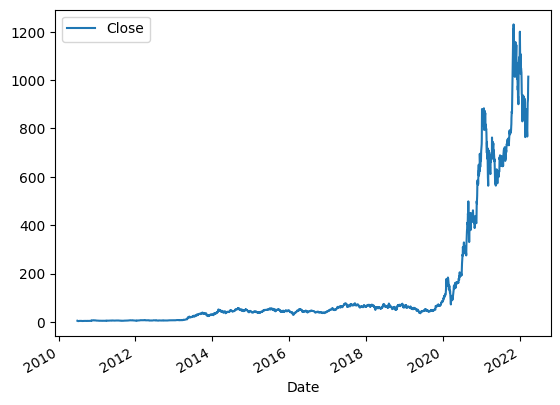

In [120]:
data.plot.line(y="Close", use_index=True)

Configure Dataset

In [121]:
data["Tomorrow"] = data["Adj Close"].shift(-1)

In [122]:
data

,Open,High,Low,Close,Adj Close,Volume,Tomorrow
Date,,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500,4.766000
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500,4.392000
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000,3.840000
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000,3.222000
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500,3.160000
...,...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500,921.159973
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200,993.979980
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500,999.109985


In [123]:
data["Target"] = (data["Tomorrow"] > data["Adj Close"]).astype(int)

In [124]:
data

,Open,High,Low,Close,Adj Close,Volume,Tomorrow,Target
Date,,,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500,4.766000,0
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500,4.392000,0
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000,3.840000,0
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000,3.222000,0
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500,3.160000,0
...,...,...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500,921.159973,1
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200,993.979980,1
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500,999.109985,1


Initial Model

In [125]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = data.iloc[:-100]
test  = data.iloc[-100:]
predictors = ["Adj Close", "Open", "High", "Low", "Volume"]

model.fit(train[predictors], train["Target"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [126]:
from sklearn.metrics import precision_score 

preds = model.predict(test[predictors])

In [127]:
preds = pd.Series(preds, index=test.index)

In [128]:
preds

Date
2021-11-01    1
2021-11-02    1
2021-11-03    1
2021-11-04    1
2021-11-05    1
             ..
2022-03-18    1
2022-03-21    1
2022-03-22    1
2022-03-23    1
2022-03-24    1
Length: 100, dtype: int64

In [129]:
precision_score(test["Target"], preds)

0.49

In [130]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

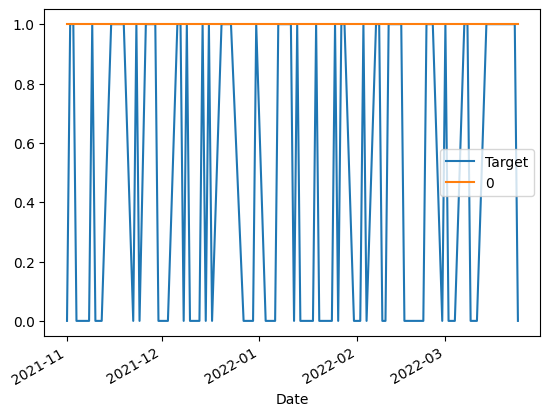

In [131]:
combined.plot()

In [132]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [133]:
def backtest(data, model, predictors, start=500, step= 100):
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [134]:
predictions = backtest(data, model, predictors)

In [135]:
predictions["Predictions"].value_counts()

Predictions
0    1409
1    1047
Name: count, dtype: int64

In [136]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5195797516714422

In [137]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.523208
0    0.476792
Name: count, dtype: float64

In [138]:
horizons = [2,5,60,250,500]
new_predictors = []

for horizon in horizons:
    rolling_averages = data.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    data[ratio_column] = data["Adj Close"] / rolling_averages["Adj Close"]

    trend_column = f"Trend_{horizon}"
    data[trend_column] = data.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [139]:
data

,Open,High,Low,Close,Adj Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_500,Trend_500
Date,,,,,,,,,,,,,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500,4.766000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500,4.392000,0,0.998743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000,3.840000,0,0.959161,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000,3.222000,0,0.932945,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500,3.160000,0,0.912489,0.0,0.767216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500,921.159973,1,1.019015,2.0,1.081584,4.0,0.968285,28.0,1.114740,134.0,1.454386,276.0
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200,993.979980,1,1.008634,2.0,1.061178,5.0,0.986693,28.0,1.132534,135.0,1.475851,277.0
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500,999.109985,1,1.038023,2.0,1.096537,5.0,1.066083,28.0,1.219942,135.0,1.587987,278.0


In [140]:
data = data.dropna()

In [141]:
data

,Open,High,Low,Close,Adj Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_500,Trend_500
Date,,,,,,,,,,,,,,,,,,
2012-06-21,6.852000,6.856000,6.368000,6.438000,6.438000,9459500,6.758000,1,0.975898,1.0,1.007133,4.0,1.011596,25.0,1.083571,120.0,1.188478,246.0
2012-06-22,6.520000,6.796000,6.492000,6.758000,6.758000,15233000,6.622000,0,1.024250,1.0,1.032134,4.0,1.064140,26.0,1.136461,121.0,1.246634,247.0
2012-06-25,6.788000,6.824000,6.550000,6.622000,6.622000,7492500,6.322000,0,0.989836,1.0,1.003577,3.0,1.045040,26.0,1.112842,120.0,1.220543,247.0
2012-06-26,6.410000,6.470000,6.278000,6.322000,6.322000,13069500,6.392000,1,0.976823,0.0,0.960907,2.0,1.000660,26.0,1.061953,119.0,1.164183,247.0
2012-06-27,6.380000,6.490000,6.314000,6.392000,6.392000,5236000,6.282000,0,1.005506,1.0,0.982417,2.0,1.014211,27.0,1.073303,119.0,1.175700,248.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-17,830.989990,875.000000,825.719971,871.599976,871.599976,22194300,905.390015,1,1.018325,2.0,1.069332,3.0,0.931597,28.0,1.074424,133.0,1.403703,276.0
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500,921.159973,1,1.019015,2.0,1.081584,4.0,0.968285,28.0,1.114740,134.0,1.454386,276.0
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200,993.979980,1,1.008634,2.0,1.061178,5.0,0.986693,28.0,1.132534,135.0,1.475851,277.0


In [142]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [143]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [144]:
predictions = backtest(data, model, new_predictors)

In [145]:
predictions["Predictions"].value_counts()

Predictions
0.0    1576
1.0     379
Name: count, dtype: int64

In [147]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5303430079155673